In [2]:
print('hello world')

hello world


In [3]:
#!pip install opencv-python

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("TensorFlow version:", tf.__version__)
print("All libraries imported successfully!")

TensorFlow version: 2.21.0
All libraries imported successfully!


In [5]:
base_path = "D:/AI COURSE/Daily_practice/PROJECTS/Retinopathy/aptos2019-blindness-detection/"

train_df = pd.read_csv(base_path + "train.csv")
test_df = pd.read_csv(base_path + "test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nFirst 5 rows of train data:")
train_df.head()

Train shape: (3662, 2)
Test shape: (1928, 1)

First 5 rows of train data:


,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


## EDA - class distribution

Label value counts:
diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


C:\Users\SAMI\AppData\Local\Temp\ipykernel_21500\2674397637.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=train_df, palette='viridis')


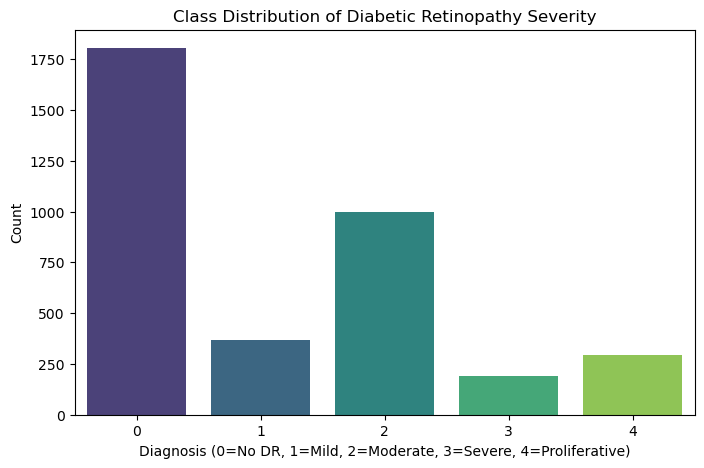

In [6]:
print("Label value counts:")
print(train_df['diagnosis'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x='diagnosis', data=train_df, palette='viridis')
plt.title('Class Distribution of Diabetic Retinopathy Severity')
plt.xlabel('Diagnosis (0=No DR, 1=Mild, 2=Moderate, 3=Severe, 4=Proliferative)')
plt.ylabel('Count')
plt.show()

## EDA - sample images

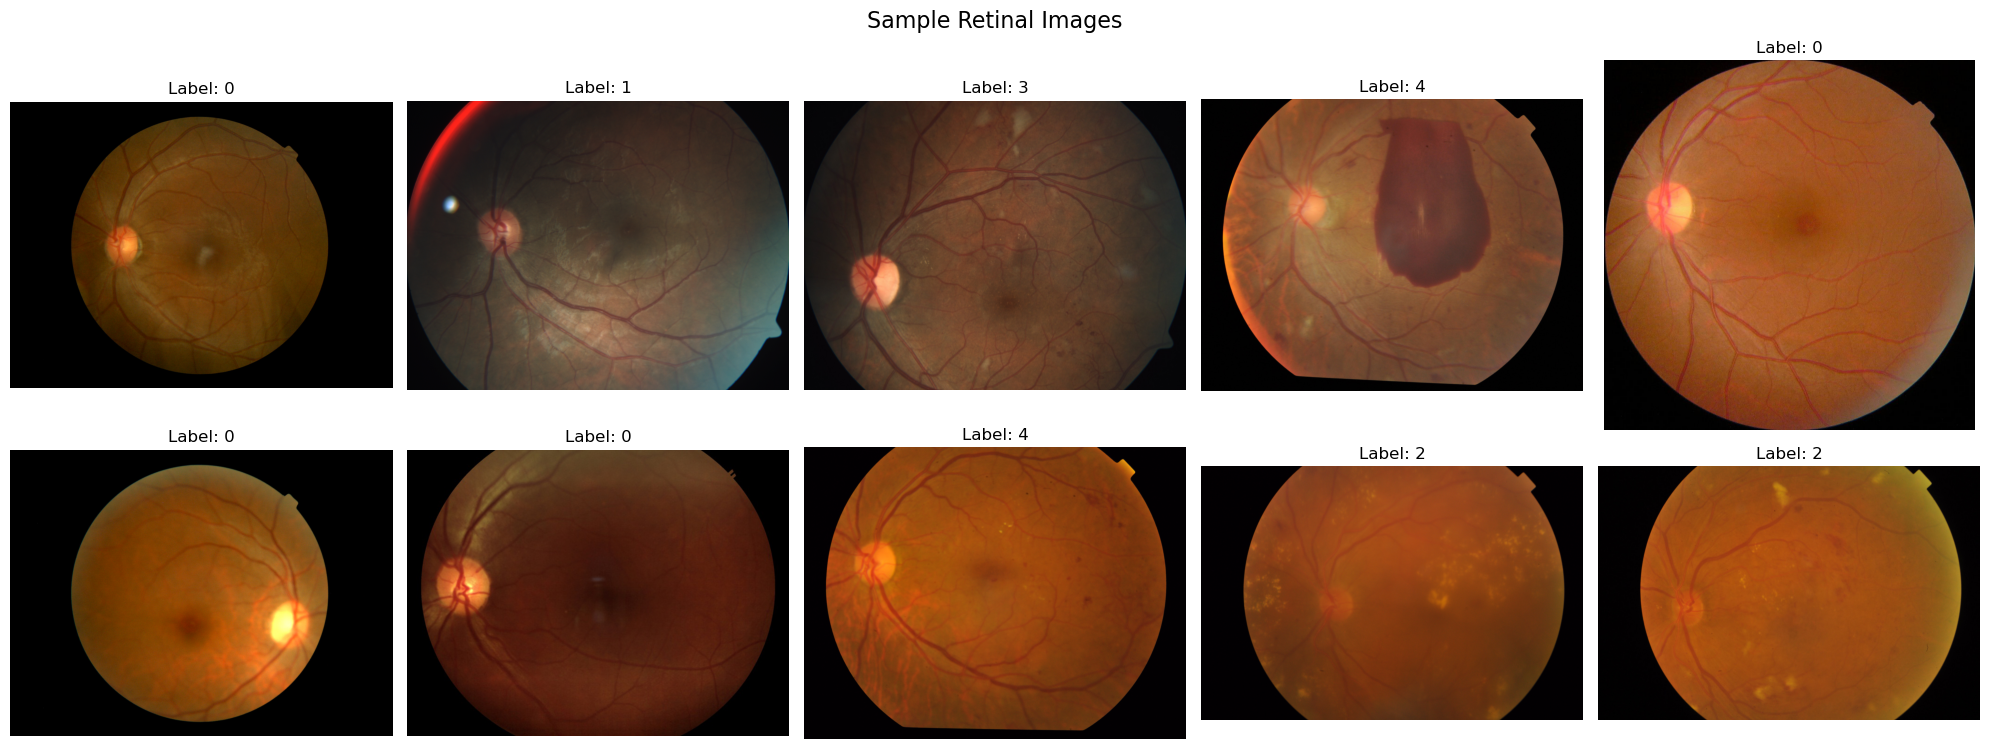

In [7]:
train_images_path = base_path + "train_images/"

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, (idx, row) in enumerate(train_df.sample(10, random_state=42).iterrows()):
    img_path = train_images_path + row['id_code'] + ".png"
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {row['diagnosis']}")
    axes[i].axis('off')

plt.suptitle('Sample Retinal Images', fontsize=16)
plt.tight_layout()
plt.show()

## preprocessing

In [8]:
# binary classification (0 = No DR, 1 = Has DR)

train_df['binary_label'] = train_df['diagnosis'].apply(lambda x: 0 if x == 0 else 1)
train_df['image_path'] = train_images_path + train_df['id_code'] + ".png"

print("Binary label distribution:")
print(train_df['binary_label'].value_counts())
train_df[['id_code', 'diagnosis', 'binary_label', 'image_path']].head()

Binary label distribution:
binary_label
1    1857
0    1805
Name: count, dtype: int64


,id_code,diagnosis,binary_label,image_path
0,000c1434d8d7,2,1,D:/AI COURSE/Daily_practice/PROJECTS/Retinopat...
1,001639a390f0,4,1,D:/AI COURSE/Daily_practice/PROJECTS/Retinopat...
2,0024cdab0c1e,1,1,D:/AI COURSE/Daily_practice/PROJECTS/Retinopat...
3,002c21358ce6,0,0,D:/AI COURSE/Daily_practice/PROJECTS/Retinopat...
4,005b95c28852,0,0,D:/AI COURSE/Daily_practice/PROJECTS/Retinopat...


## training & validation 

In [9]:
train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['binary_label']
)

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))

Training samples: 2929
Validation samples: 733


## data generators

In [10]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_data,
    x_col='image_path',
    y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw'
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    x_col='image_path',
    y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw'
)

Found 2929 validated image filenames.
Found 733 validated image filenames.


## model (transf learning)

In [11]:
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## training the model

In [12]:
callbacks = [
    EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=callbacks
)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1245s 13s/step - accuracy: 0.5104 - auc: 0.5133 - loss: 0.7065 - val_accuracy: 0.4925 - val_auc: 0.5000 - val_loss: 0.7052 - learning_rate: 0.0010
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1098s 12s/step - accuracy: 0.5005 - auc: 0.4880 - loss: 0.7004 - val_accuracy: 0.5075 - val_auc: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1426s 16s/step - accuracy: 0.5060 - auc: 0.5113 - loss: 0.6943 - val_accuracy: 0.5075 - val_auc: 0.5000 - val_loss: 0.6937 - learning_rate: 0.0010
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1094s 11s/step - accuracy: 0.4923 - auc: 0.4856 - loss: 0.6937 - val_accuracy: 0.5075 - val_auc: 0.5000 - val_loss: 0.6931 - learning_rate: 0.0010
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1061s 12s/step - accuracy: 0.5032 - auc: 0.5018 - loss: 0.6943 - val_accuracy: 0.5075 - val_auc: 0.5000 - val_loss: 0.6935 - learning_rate: 0.0010
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 1470s 16s/step - accuracy: 0.4950 - a

## plotting training history

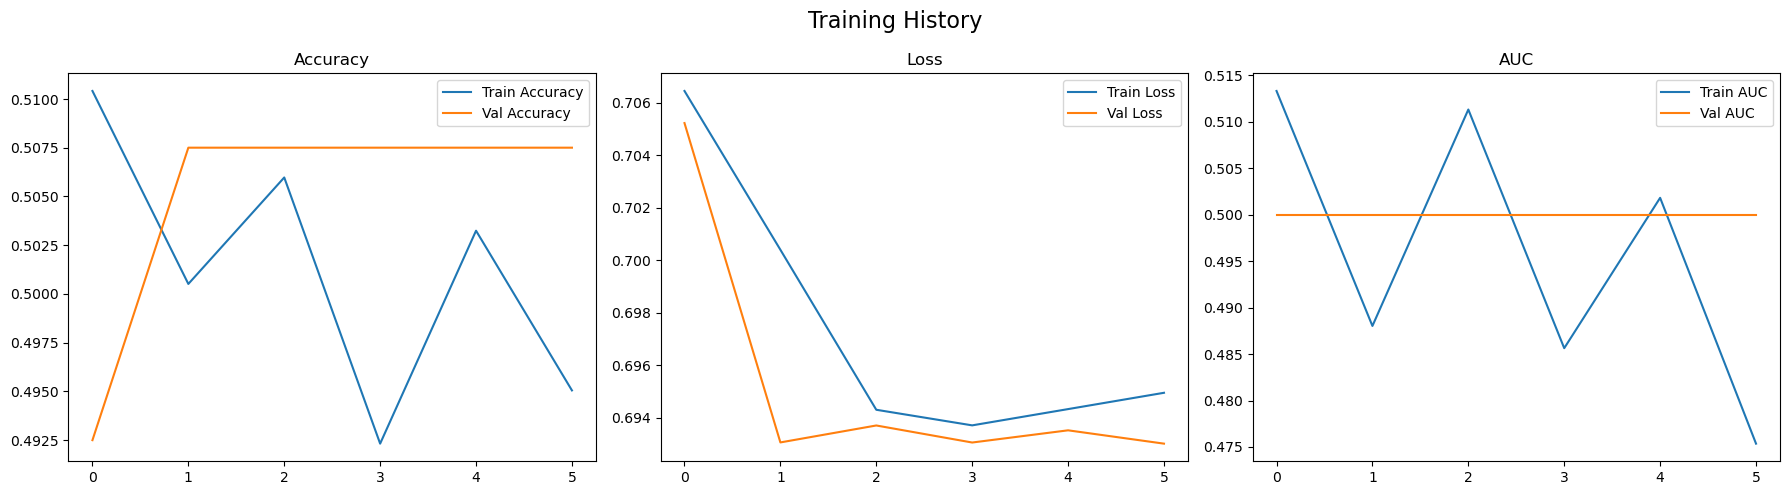

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss')
axes[1].legend()

axes[2].plot(history.history['auc'], label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC')
axes[2].legend()

plt.suptitle('Training History', fontsize=16)
plt.tight_layout()
plt.show()

## confusion matrix , classification report

Found 733 validated image filenames.
23/23 ━━━━━━━━━━━━━━━━━━━━ 68s 3s/step
Classification Report:
              precision    recall  f1-score   support

       No DR       0.49      1.00      0.66       361
      Has DR       0.00      0.00      0.00       372

    accuracy                           0.49       733
   macro avg       0.25      0.50      0.33       733
weighted avg       0.24      0.49      0.33       733



e:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
e:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


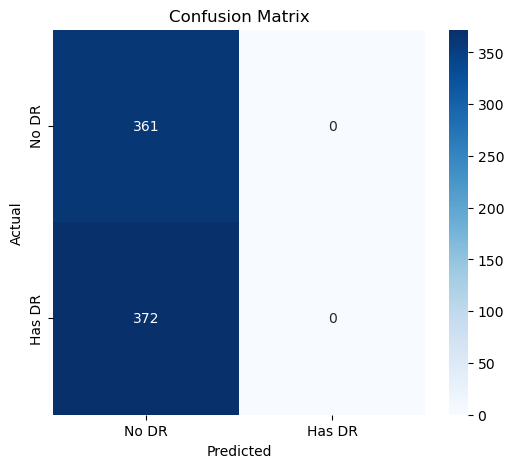

In [14]:
val_generator_eval = val_datagen.flow_from_dataframe(
    dataframe=val_data,
    x_col='image_path',
    y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    shuffle=False
)

y_pred_probs = model.predict(val_generator_eval)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = val_data['binary_label'].values

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=['No DR', 'Has DR']))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No DR', 'Has DR'],
            yticklabels=['No DR', 'Has DR'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## sample predictions visualization

Found 10 validated image filenames.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


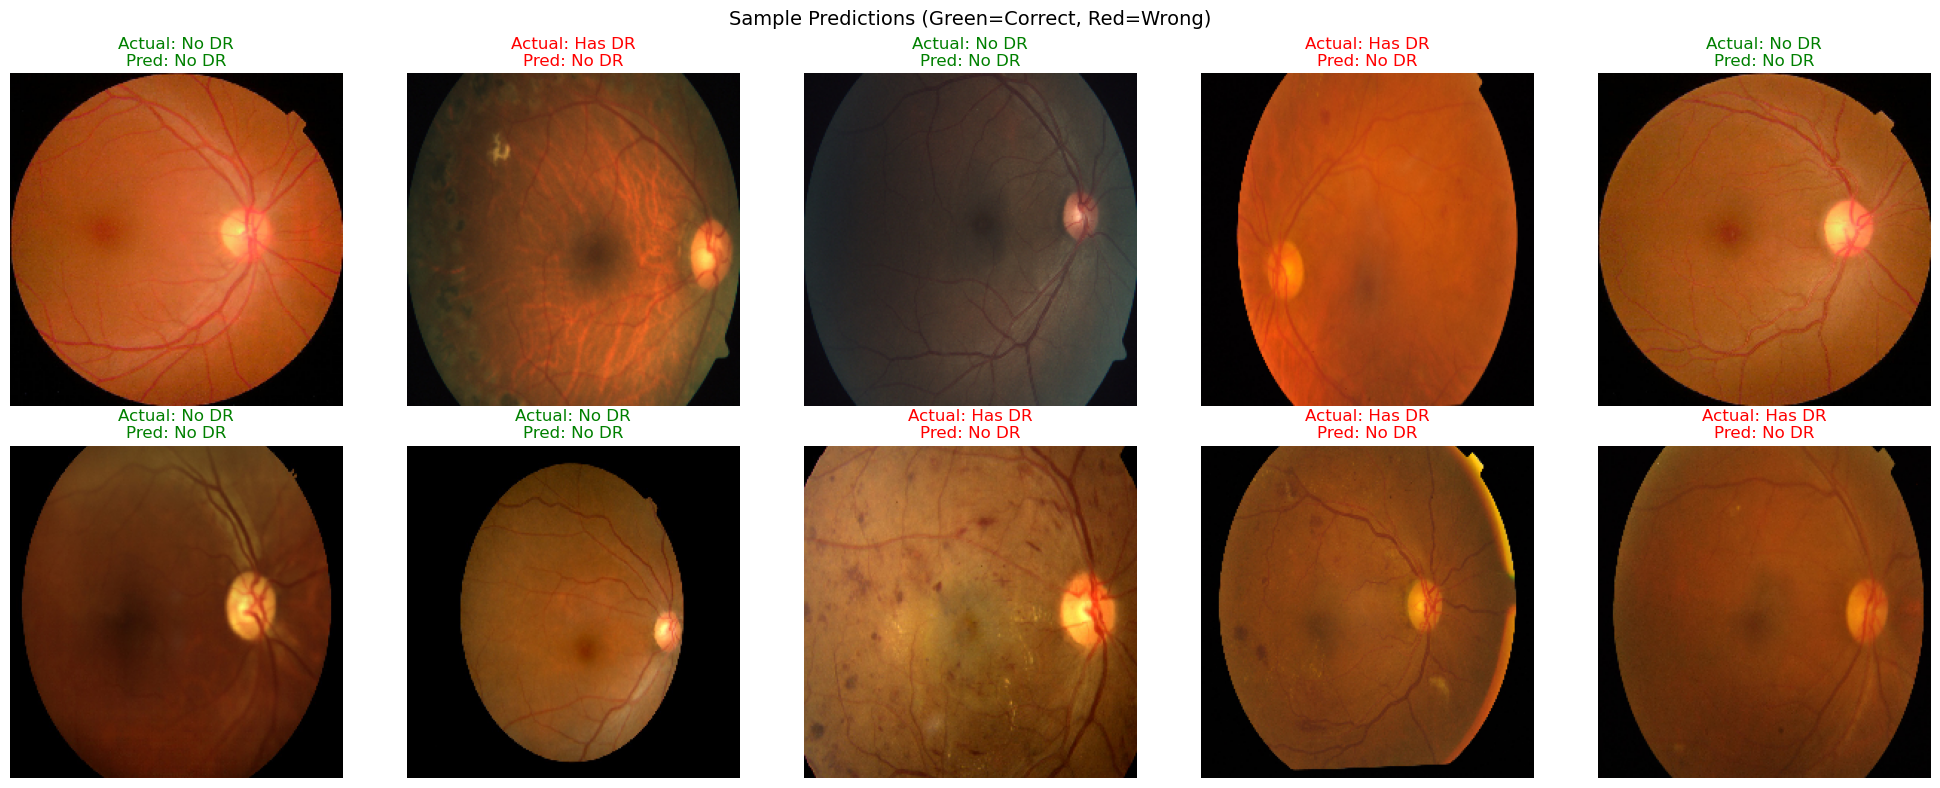

In [15]:
val_generator_viz = val_datagen.flow_from_dataframe(
    dataframe=val_data.head(10),
    x_col='image_path',
    y_col='binary_label',
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=10,
    class_mode='raw',
    shuffle=False
)

images, labels = next(val_generator_viz)
preds = model.predict(images)
pred_labels = (preds > 0.5).astype(int).flatten()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i in range(10):
    axes[i].imshow(images[i])
    actual = "No DR" if labels[i] == 0 else "Has DR"
    predicted = "No DR" if pred_labels[i] == 0 else "Has DR"
    color = "green" if labels[i] == pred_labels[i] else "red"
    axes[i].set_title(f"Actual: {actual}\nPred: {predicted}", color=color)
    axes[i].axis('off')

plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=14)
plt.tight_layout()
plt.show()

## model save

In [16]:
model.save(base_path + "retinopathy_model.h5")
print("Model saved ")

Model saved 
